# Analysis of the unique two extremal spheres with one puncture and three boundary components

There are exactly two extremal disc configurations associated to spheres with one puncture and three boundary components and the side-pairing pattern of the associated Fuchsian triangle group is given by the permutation (1,2)(3,4)(5,10)(6,7)(8,9) in both cases (but they differ by the election of pre-boundary and pre-cuspidal vertices).

### The following cells are shared by all the extremal disc configurations. They include the functions needed for finding the centers of hidden extremal discs.

In [1]:
g=0 #Genus.
n=1 #Number of cusps.
b=3 #Number of boundary components.
m=12*g+4*n+5*b-6 #Number of sides of the fundamental domain.

half_alpha=find_root(2*sin(x)-3*(sin(2*x)*(cos(2*x)-2*sin(x)^2)+2*sin(x)*cos(2*x)*sqrt(2*cos(2*x)))+4*(sin(2*x)*(cos(2*x)-2*sin(x)^2)+2*sin(x)*cos(2*x)*sqrt(2*cos(2*x)))^3==0, 0.01, pi/m)

alpha=2*half_alpha #Measure of the angles in the equilateral triangles of DeBlois decomposition.
beta=arcsin(2*sin(half_alpha)) #Measure of the positive angles of the horocyclic ideal triangles of DeBlois decomposition.
gamma=N((pi-(m-n-2*b)*half_alpha-n*beta)/b) #Measure of the non-right angles of the Saccheri quadrilaterals of DeBlois decomposition.
radius=arccosh(1/(2*sin(half_alpha))) #Extremal radius.

#Lengths and distances in the fundamental domain:
fd_half_edge=arccosh(cos(half_alpha)/sin(pi/3))
fd_edge=2*fd_half_edge #Length of the sides of type II.
fd_edges_boundary=radius+arccosh(cos(half_alpha)/sin(pi/3)) #Length of the sides of type III.
fd_boundary=2*arcsinh(tan(radius)) #Length of the sides of type IV.

fd_distance_vertex=N(arccosh((cos(half_alpha)*cos(pi/3))/(sin(half_alpha)*sin(pi/3))))
#Distance from the origin (the center of our fundamental domain) to the proper non-right vertices of the fundamental domain.
fd_dist_bvertex=N(arccosh(sqrt(cosh(2*radius))))
#Distance from the origin to the proper right vertices of the fundamental domain.
fd_first_distance, fd_second_distance=2*radius, 2*fd_dist_bvertex #First two admissible distances.

#Euclidean version of all the lenghts and distances:
r_euc=tanh(radius/2)
fd_edge_euc=tanh(fd_edge/2)
fd_boundary_euc=tanh(fd_boundary/2)
fd_edges_boundary_euc=tanh(fd_edges_boundary/2)
fd_dist_vertex_euc=tanh(fd_distance_vertex/2)
fd_dist_bvertex_euc=tanh(fd_dist_bvertex/2)
second_distance_euc=tanh(fd_second_distance/2)

In [2]:
#The following function calculates the generalized circle that passes through three fixed points a,b,c of the hyperbolic plane.
#Inputs: a,b,c (points of the Poincaré disc model), col ('str', default=0), style ('str')
#Outputs: if col!=0, ThreePointsCircle returns the plot of the generalized circle C that passes through a,b,c of color col and linestyle style,
#while if col==0 it returns only the algebraic expression of C.

def ThreePointsCircle(a,b,c,col=0,style='-'): 
    x,y=var('x'), var('y')
    u,v,w=var('u'),var('v'),var('w')
    
    if a in PD:
        a_1=N(a.coordinates())
    else:
        a_1=N(a)
    if b in PD:
        b_1=N(b.coordinates())
    else:
        b_1=N(b)
    if c in PD:
        c_1=N(c.coordinates())
    else:
        c_1=N(c)
        
    if abs((a_1-b_1)*(b_1-c_1)*(c_1-a_1))<10^(-5): return 'The three points introduced are not all different.'
    else:
        if abs(((c_1-a_1)/(b_1-a_1)).imag())<10^(-5): 
            if abs((b_1).real()-(a_1).real())>10^(-5):
                circle=(y-u*x-v==0)
                coc=(a_1.imag()-b_1.imag())/(a_1.real()-b_1.real())
                eq=circle.subs(u=coc).subs(v=a_1.imag()-a_1.real()*coc)
            else:
                eq=(x-a_1.real()==0)
        else:
            circle=((x-u)^2+(y-v)^2-w^2==0)
            eq1=circle.subs(x==a_1.real()).subs(y==a_1.imag())
            eq2=circle.subs(x==b_1.real()).subs(y==b_1.imag())
            eq3=circle.subs(x==c_1.real()).subs(y==c_1.imag())
            coef=solve([eq1,eq2,eq3],u,v,w)
            control=min(abs(N(coef[1][0].rhs())),abs(N(coef[1][1].rhs())),abs(N(coef[1][2].rhs())))
            if control>10^10: circle=((u/v)*x+y+(u^2+v^2-w^2)/(-2*v)==0)
            eq=circle.subs(u=N(coef[1][0].rhs())).subs(v=N(coef[1][1].rhs())).subs(w=N(coef[1][2].rhs()))
        
        if col==0: return eq
        else:
            return implicit_plot(eq, (x,-1,1), (y,-1,1), color=col, axes=false, linestyle=style, linewidth=0.5)

In [3]:
#The following function calculates the set of points of the hyperbolic plane that move a fixed distance under the action of a hyperbolic isometry or a glide-reflection.
#Inputs: s (hyperbolic isometry or glide-reflection), d ('float'), c ('str', default=0)
#Outputs: if c!=0, banana returns the plot of the bananas of the isometry s associated to the distance d in color c, while if c==0 it returns the algebraic expression of the bananas.

def banana(s,d,c=0):
    origin=PD.get_point(0+0*I)
    T=N((s*s).translation_length()/2)
    
    if bool(abs(T-d)<10^(-5)):
        if bool(c==0)==false:
            return plot(s.axis(), color=c)
        else:
            return s.axis()
        
    if bool(s.classification()=='hyperbolic'):
        dist_banana_axis=N(arccosh(sinh(d/2)/sinh(T/2)))
    elif bool(s.classification()=='orientation-reversing hyperbolic'):
        dist_banana_axis=N(arccosh(cosh(d/2)/cosh(T/2)))
        
    initial,final=N((s*s).axis().ideal_endpoints()[0].coordinates()),N((s*s).axis().ideal_endpoints()[1].coordinates())
    middle=(initial+final)/2
    if abs(middle)<10^(-5):
        border_1, border_2= cos(arg(initial)+pi/2)+I*sin(arg(initial)+pi/2), cos(arg(initial)+3*pi/2)+I*sin(arg(initial)+3*pi/2)
    else:
        border_1=cos(arg(middle))+I*sin(arg(middle))
        border_2=-border_1

    dist_origin_axis=(s*s).axis().dist(origin)
    
    if bool(d>T) or bool(abs(d-T)<10^(-5)):
        mod_1=tanh(abs(dist_origin_axis-dist_banana_axis)/2)
        mod_2=tanh((dist_origin_axis+dist_banana_axis)/2)
        argu=arg(border_1)
        if bool(dist_banana_axis<dist_origin_axis) or bool(abs(dist_banana_axis-dist_origin_axis)<10^(-5)):
            part_1=ThreePointsCircle(initial,final,mod_1*(cos(argu)+I*sin(argu)), c)
            part_2=ThreePointsCircle(initial,final,mod_2*(cos(argu)+I*sin(argu)), c)
        else:
            part_1=ThreePointsCircle(initial,final,mod_1*(cos(argu+pi)+I*sin(argu+pi)), c, '-')
            part_2=ThreePointsCircle(initial,final,mod_2*(cos(argu)+I*sin(argu)), c, ':')
        if bool(c==0)==false:
            return part_1+part_2
        else:
            return [part_1,part_2]
    else:
        return 'ERROR'

In [4]:
#The following function calculates the set of points of the hyperbolic plane that move a fixed distance under the action of a parabolic isometry.
#Inputs: theta ('float'), distances (list of lists [[a_1,...], [a_2,...],...,[a_n,...]] with ai an unsigned float), m ('int'), c ('str', default=0)
#Outputs: if c!=0, bananapar returns the plot of the banana of a parabolic isometry fixing the ideal point exp(I*theta) and associated to the distance distances[m][0] in color c,
#while if c==0 it returns only the algebraic expression of the banana.

def bananapar(theta,distances,m,c=0):
    var('x y')
    a=cos(theta)
    b=sin(theta)
    d=sinh(distances[0][0]/2)/sinh(distances[m][0]/2)
    
    #Poisson kernel: P(z,w)=(1-|z|^2)/|z-w|^2=Re(f(z)) with f(z)=(w+z)/(w-z).
    z1=(d*a+sqrt(1-b^2*d^2))/(d+1)
    z2=(d*a-sqrt(1-b^2*d^2))/(d+1)
    
    if abs(theta)>10^(-5) and abs(theta-pi)>10^(-5):
        lambda1=(z1^2-1)/(2*(z1*a-1))
        lambda2=(z2^2-1)/(2*(z2*a-1))
    elif abs(theta-pi)<=10^(-5):
        lambda1=(1-z1)/2
        lambda2=(1-z2)/2
    else:
        lambda1=(z1+1)/2
        lambda2=(z2+1)/2

    eq1=(x-lambda1*a)^2+(y-lambda1*b)^2-(1-lambda1)^2
    eq2=(x-lambda2*a)^2+(y-lambda2*b)^2-(1-lambda2)^2
    if c==0: return (eq1,eq2)
    else: return implicit_plot(eq1==0, (x, -1, 1), (y, -1, 1), color=c, linestyle='--', linewidth=0.5)+implicit_plot(eq2==0, (x, -1, 1), (y, -1, 1), color=c,linewidth=0.5)

In [5]:
#The following function returns the intersection points of two generalized circles in the hyperbolic plane.
#Inputs: pol1,pol2 ('symbolic expressions')
#Outputs: list of points in the hyperbolic plane in which the generalized circles pol1==0 and pol2==0 intersect.

def coord_intersection(pol1,pol2):
    x,y=var('x'), var('y')
    R=PolynomialRing(RR,['x','y'])
    gr1,gr2=2,2
    if R(pol1).coefficient({x:0,y:2})==0 and R(pol1).coefficient({x:2,y:0})==0:
        gr1=1
    if R(pol2).coefficient({x:0,y:2})==0 and R(pol2).coefficient({x:2,y:0})==0:
        gr1=1
    
    if gr1==1 and gr2==1:
        sol=solve([pol1,pol2],x,y)
        solution=[N(sol[0][0].rhs())+N(sol[0][1].rhs())*I]
        return [z for z in solution if abs(z)<=1]
    
    elif gr1==2 and gr2==2:
        sol=solve([pol1,pol1-pol2],x,y)
        if all([imag(sol[t][0].rhs())==0 and imag(sol[t][1].rhs())==0 for t in [0..len(sol)-1]]):
            solution=[N(sol[t][0].rhs())+N(sol[t][1].rhs())*I for t in [0..len(sol)-1]]
            return [z for z in solution if abs(z)<=1]
        else: return []
        
    else:
        sol=solve([pol1,pol2],x,y)
        if all([imag(sol[t][0].rhs())==0 and imag(sol[t][1].rhs())==0 for t in [0..len(sol)-1]]):
            solution=[N(sol[t][0].rhs())+N(sol[t][1].rhs())*I for t in [0..len(sol)-1]]
            return [z for z in solution if abs(z)<=1]
        else: return []

In [6]:
#The following function returns the elliptic isometry of order 2 in the hyperbolic plane that relates two given points.
#Inputs: p,q (points in the Poincaré disc model)
#Outputs: Elliptic isometry of order two that sends p to q and viceversa.

def rotationpi(p,q):
    p1=PD.get_point(p)
    q1=PD.get_point(q)
    geod=PD.get_geodesic(p1,q1)
    mid_point=geod.midpoint().coordinates()
    
    rot_matrix=matrix([[I, mid_point*(-I)], [mid_point.conjugate()*I, -I]])
    rotation=PD.get_isometry(rot_matrix)
    
    can_matrix=matrix([[I, 0], [0, -I]])
    can_rotation=PD.get_isometry(can_matrix)
    rotationpi=rotation*can_rotation*rotation^(-1)
    return rotationpi

## Configuration 1

In [7]:
#Vertices and edges of the fundamental domain:
PD=HyperbolicPlane().PD()

fd_vertices=[fd_dist_bvertex_euc*(cos(gamma/2)-I*sin(gamma/2))]
fd_vertices+=[fd_dist_bvertex_euc*(cos(gamma/2)+I*sin(gamma/2))]
fd_vertices+=[fd_dist_vertex_euc*(cos(gamma+half_alpha)+I*sin(gamma+half_alpha))]
fd_vertices+=[fd_dist_bvertex_euc*(cos(3*gamma/2+alpha)+I*sin(3*gamma/2+alpha))]
fd_vertices+=[fd_dist_bvertex_euc*(cos(5*gamma/2+alpha)+I*sin(5*gamma/2+alpha))]
fd_vertices+=[fd_dist_vertex_euc*(cos(3*gamma+3*half_alpha)+I*sin(3*gamma+3*half_alpha))]
fd_vertices+=[fd_dist_vertex_euc*(cos(3*gamma+5*half_alpha)+I*sin(3*gamma+5*half_alpha))]
fd_vertices+=[fd_dist_bvertex_euc*(cos(7*gamma/2+3*alpha)+I*sin(7*gamma/2+3*alpha))]
fd_vertices+=[fd_dist_bvertex_euc*(cos(9*gamma/2+3*alpha)+I*sin(9*gamma/2+3*alpha))]
fd_vertices+=[fd_dist_vertex_euc*(cos(5*gamma+7*half_alpha)+I*sin(5*gamma+7*half_alpha))]
fd_vertices+=[cos(5*gamma+beta+4*alpha)+I*sin(5*gamma+beta+4*alpha)]
fd_vertices+=[fd_dist_vertex_euc*(cos(5*gamma+2*beta+9*half_alpha)+I*sin(5*gamma+2*beta+9*half_alpha))]
fd_vertices+=[fd_dist_vertex_euc*(cos(5*gamma+2*beta+11*half_alpha)+I*sin(5*gamma+2*beta+11*half_alpha))]

fd_edges=[PD.get_geodesic(fd_vertices[k],fd_vertices[k+1]) for k in [0..m-2]]
fd_edges+=[PD.get_geodesic(fd_vertices[0],fd_vertices[-1])]

fd_midpoints=[r_euc*(1+0*I)]
fd_midpoints+=[(r_euc-0.03)*(cos(gamma)+I*sin(gamma))]
fd_midpoints+=[(r_euc-0.03)*(cos(gamma+alpha)+I*sin(gamma+alpha))]
fd_midpoints+=[r_euc*(cos(2*gamma+alpha)+I*sin(2*gamma+alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(3*gamma+alpha)+I*sin(3*gamma+alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(3*gamma+2*alpha)+I*sin(3*gamma+2*alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(3*gamma+3*alpha)+I*sin(3*gamma+3*alpha))]
fd_midpoints+=[r_euc*(cos(4*gamma+3*alpha)+I*sin(4*gamma+3*alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(5*gamma+3*alpha)+I*sin(5*gamma+3*alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(5*gamma+4*alpha)+I*sin(5*gamma+4*alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(5*gamma+2*beta+4*alpha)+I*sin(5*gamma+2*beta+4*alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(5*gamma+2*beta+5*alpha)+I*sin(5*gamma+2*beta+5*alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(gamma)-I*sin(gamma))]

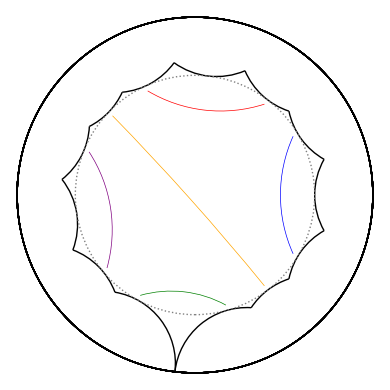

In [8]:
identifications=plot(PD.get_geodesic(fd_midpoints[1], fd_midpoints[-1]), thickness=0.5)
identifications+=plot(PD.get_geodesic(fd_midpoints[2], fd_midpoints[4]), thickness=0.5, color='red')
identifications+=plot(PD.get_geodesic(fd_midpoints[5], fd_midpoints[11]), thickness=0.5, color='orange')
identifications+=plot(PD.get_geodesic(fd_midpoints[6], fd_midpoints[8]), thickness=0.5, color='purple')
identifications+=plot(PD.get_geodesic(fd_midpoints[9], fd_midpoints[10]), thickness=0.5, color='green')

polygon=Graphics()
for edge in fd_edges:
    polygon+=plot(edge, axes=false, color='black')

fundamental_domain=polygon+identifications

fundamental_domain+circle((0,0), r_euc, color='grey', thickness=1, linestyle='dotted')

In [9]:
#The following function plots the image of the fundamental domain by an isometry.
#Inputs: g (isometry in the Poincaré disc model), col ('str'), style ('str', default='-'), w ('float', default='1')
#Outputs: It returns a figure with the image by g of the fundamental domain, where the lines have color col, linestyle style and thickness w.

def movepolygon(g, col, style='-', w=1):
    global fd_edges
    g_fd=Graphics()
    g_fd_edges=[g*edge for edge in fd_edges]
    for j in [0..m-1]:
        g_fd+=plot(g_fd_edges[j], color=col, axes=False, linestyle=style, thickness=w)
    return g_fd

In [10]:
#Definition of the side-pairing transformations:
ref=[]
for j in [0..len(fd_edges)-1]:
    ref.append(fd_edges[j].reflection_involution())
    
simbas1=PD.get_geodesic(fd_midpoints[0],PD(0+0*I)).reflection_involution()
simbas2=PD.get_geodesic(fd_midpoints[3],PD(0+0*I)).reflection_involution()
simbas3=PD.get_geodesic(fd_midpoints[7],PD(0+0*I)).reflection_involution()
simbas4=PD.get_geodesic(fd_vertices[10],PD(0+0*I)).reflection_involution()

g_mid=PD.get_geodesic(fd_midpoints[5],fd_midpoints[-2])
simbas5=g_mid.perpendicular_bisector().reflection_involution()

side_pairings=[ref[0],simbas1*ref[1],simbas2*ref[2],ref[3],simbas2*ref[4],simbas5*ref[5],simbas3*ref[6],ref[7],simbas3*ref[8]]
side_pairings+=[simbas4*ref[9],simbas4*ref[10],simbas5*ref[11],simbas1*ref[12]]

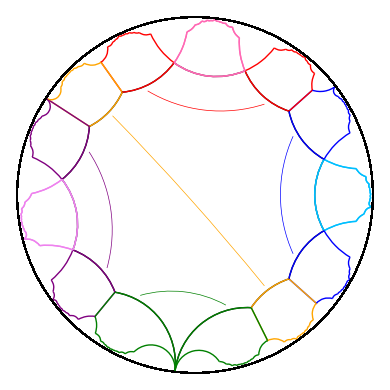

In [11]:
polygon_color=fundamental_domain
list1=[0,1,2,3,5,6,7,9]
col1=['deepskyblue','blue','red','hotpink','orange','purple','violet','green']

for j in [0..len(list1)-1]:
    polygon_color+=movepolygon(side_pairings[list1[j]], col1[j])+movepolygon(side_pairings[list1[j]]^(-1), col1[j])
polygon_color

### Search of the preimages of extremal disc centers using the "bananas' method".

In [12]:
#Construction of a short list of admissible distances:
lst_index=[[j] for j in [0..m-1]]
origin=PD(0+0*I)
ln=2

for i in range(ln):
    lst_index_aux=copy(lst_index)
    for lst in lst_index_aux:
        for j in [0..m-1]:
            lst_index+=[lst+[j]]

distances_list=[]
pnts=[origin]
simbas=PD.get_geodesic(1,-1).reflection_involution()

for lst in lst_index: #Construction of isometries given as the product of at most three side-pairings of the fundamental domain.
    g=simbas*simbas^(-1)
    for j in [0..len(lst)-1]: g*=side_pairings[lst[j]]
    pt=g*origin
    distances_list+=[(origin.dist(pt), lst, g , g.classification())]
    pnts+=[pt]

In [13]:
#Refinement of the distances in distances_list, taking out the elements that repeat previous admissible distances:
distances_list.sort()
distances_list_ref=[]
k=0

while distances_list[k][0]==0: k+=1

distances_list_ref+=[distances_list[k]]

for j in [k..len(distances_list)-2]:
    if abs(distances_list[j+1][0]-distances_list[j][0])>10^(-5):
        distances_list_ref+=[distances_list[j+1]]
len(distances_list_ref)

326

In [14]:
#The first two distances of distances_list_ref coincide with the first two admissible distances we know theoretically.
abs(distances_list_ref[0][0]-fd_first_distance), N(abs(distances_list_ref[1][0]-fd_second_distance))

(1.08801856413265e-13, 1.19904086659517e-14)

In [15]:
#Refinement of the isometries in distances_list, taking out the elements that repeat previous isometries:
list_by_distances=[[] for j in [0..len(distances_list_ref)-1]] #We group isometries by their associated admissible distances.
l=0
d=distances_list_ref[0][0]

for j in [k..len(distances_list)-1]:
    if abs(distances_list[j][0]-d)<10^(-3): list_by_distances[l]+=[distances_list[j]]
    else:
        list_by_distances[l+1]+=[distances_list[j]]
        l+=1
        d=distances_list_ref[l][0]
        
isometries_t=[]
for k in [0..len(list_by_distances)-1]:
    isometries=[]
    for j in [0..len(list_by_distances[k])-1]:
        test=0
        s=0
        isometry=list_by_distances[k][j][2]
        while test==0 and s<len(isometries):
            a=(isometry*PD(0)).coordinates()-(isometries[s]*PD(0)).coordinates()
            b=(isometry*PD(1/2)).coordinates()-(isometries[s]*PD(1/2)).coordinates()
            c=(isometry*PD(-1/2)).coordinates()-(isometries[s]*PD(-1/2)).coordinates()
            if abs(a)<10^(-5) and abs(b)<10^(-5) and abs(c)<10^(-5) and (isometry*isometries[s]).preserves_orientation()==True:
                test=1 #isometry*isometries[s]==Id.
            s+=1
        if test==0: 
            isometries+=[isometry]
    isometries_t+=isometries

Once we have computed a reasonable amount of admissible distances of this extremal disc configuration, we are going to plot the a set of bananas needed to cover the whole fundamental domain with the closure of the regions they bound.

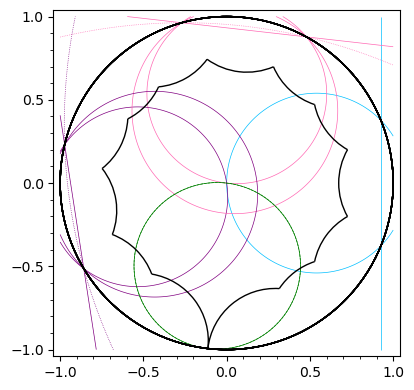

In [16]:
good_side_pairings=[]

for g in side_pairings:
    if g.classification()=='hyperbolic' or g.classification()=='orientation-reversing hyperbolic':
        good_side_pairings.append(g)

polygon_bananas1=polygon
list1_2=[0,1,4]
col1_2=['deepskyblue','hotpink','purple']

for k in [0..len(list1_2)-1]:
    polygon_bananas1+=banana(good_side_pairings[list1_2[k]],fd_first_distance,col1_2[k])

polygon_bananas1+=banana(good_side_pairings[list1_2[1]],fd_second_distance,col1_2[1])
polygon_bananas1+=banana(good_side_pairings[list1_2[2]],fd_second_distance,col1_2[2])
polygon_bananas1+=bananapar(5*gamma+beta+4*alpha,distances_list_ref,0,'green')

polygon_bananas1.show(ymax=1, ymin=-1)

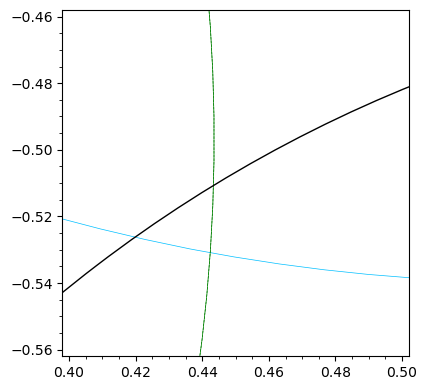

In [17]:
polygon_bananas1.show(xmin=0.4,xmax=0.5,ymin=-0.56,ymax=-0.46) #The intersection point is outside the fundamental domain.

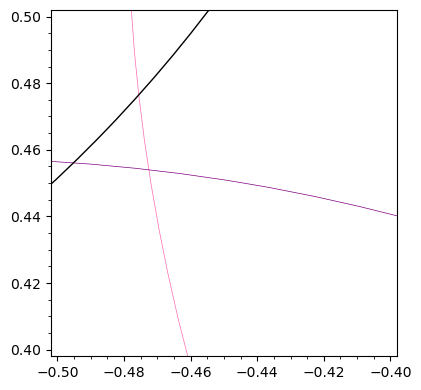

In [18]:
polygon_bananas1.show(xmax=-0.4,xmin=-0.5,ymax=0.5,ymin=0.4)

As fd_first_distance and fd_second_distance are the two smallest admissible distances, we do not have to calculate more bananas: if d1\<d2, the bananas of a hyperbolic isometry s associated to the distance d1 are contained in the region bounded by the bananas of s associated to the distance d2, while the banana of a parabolic transformation s associated to d1 is a horocycle contained in the horoball bounded by the banana of s associated to the distance d2. Therefore, as the closure of the regions bounded by the bananas represented in the previous figure cover all the fundamental domain, we do not have to take more bananas: if a point is at the interior of the region bounded by the bananas associated to the distance fd_first_distance, there is no admissible banana of this side-pairing that passes through this point and the same happens in the interior of the region bounded by the bananas of good_side_pairings[k] associated to fd_second_distance minus the region bounded by the bananas of good_side_pairings[k] associated to fd_first_distance for k=1,4.

In particular, the preimages of the extremal disc centers must be on the bananas illustrated in the previous figure. In fact, if we consider the open sets given by the interior of the regions described previously and we take their union, we will be covering all the points of the fundamental domain except two, one of them the origin (which we know is the preimage of an extremal disc centre by construction). Therefore, we only need to analyse the situation of the other special point, which is the only other candidate to be the preimage of an extremal disc center. In the previous figure, there are only pink and purple bananas intersecting at this point. Now, we will see that there cannot be any orange banana passing through this point, so it cannot be the preimage of an extremal disc center.

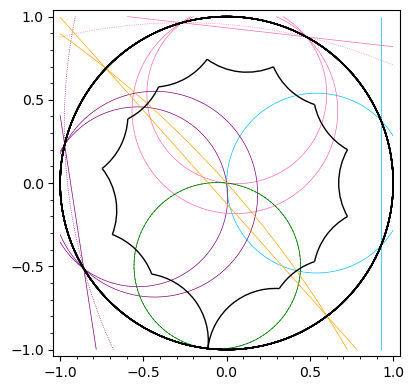

In [19]:
polygon_bananas2=polygon_bananas1

polygon_bananas2+=banana(side_pairings[5], fd_first_distance, 'orange')

polygon_bananas2.show(ymin=-1,ymax=1)

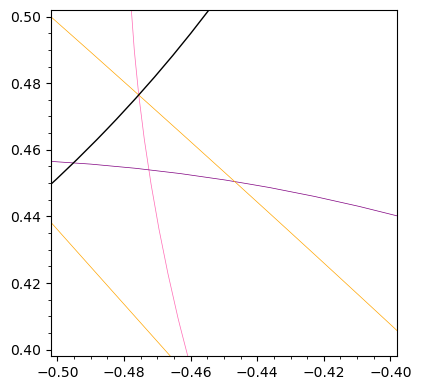

In [20]:
polygon_bananas2.show(xmax=-0.4,xmin=-0.5,ymax=0.5,ymin=0.4)

The special point is inside the region bounded by the hyperbolic bananas of side_pairings[5] associated to the first admissible distance fd_first_distance and there is no admissible banana of side_pairings[5] passing through any point in that region, so this point is not the preimage of an extremal disc center. We can numerically see that it does not move properly under that side-pairing:

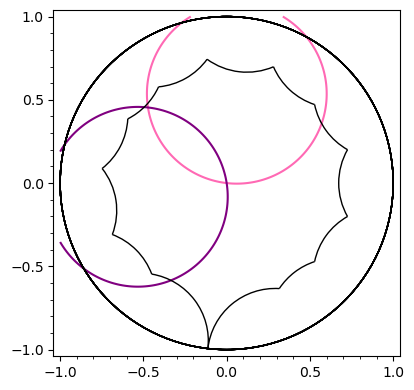

In [21]:
banana1=banana(good_side_pairings[list1_2[1]],fd_first_distance)[0]
banana2=banana(good_side_pairings[list1_2[2]],fd_first_distance)[0]

implicit_plot(banana1,(x, -1, 1),(y, -1, 1),color='hotpink')+implicit_plot(banana2,(x, -1, 1),(y, -1, 1),color='purple')+polygon

In [22]:
coord_intersection(banana1,banana2)

[-0.472605408537207 + 0.454049636816482*I,
 -1.05471187339390e-15 + 5.82867087928207e-16*I]

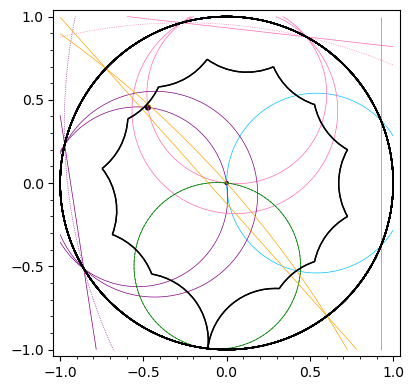

In [23]:
intersection_p=coord_intersection(banana1,banana2)[0]
bananas_point=polygon+polygon_bananas2+points([intersection_p],color='black', size='20')+points([0+0*I],color='black')
bananas_point.show(ymin=-1,ymax=1)

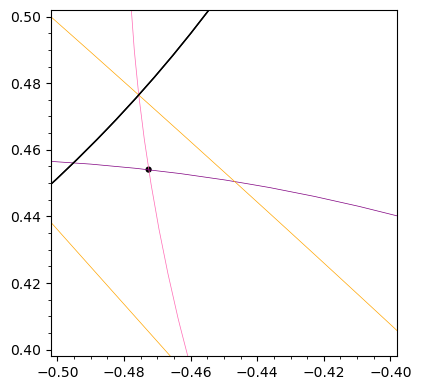

In [24]:
bananas_point.show(xmax=-0.4,xmin=-0.5,ymax=0.5,ymin=0.4) 

In [25]:
(side_pairings[5]*PD(intersection_p)).dist(PD(intersection_p)), fd_first_distance

(3.25793043656981, 3.263355322001952)

As the origin is the only candidate to be the preimage of an extremal disc center in the fundamental domain, the extremal sphere with one puncture and three boundary components described by this extremal disc configuration has exactly one extremal disc, centered at the projection of the origin.

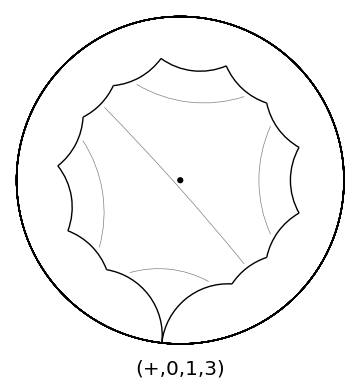

In [26]:
identifications_g=plot(PD.get_geodesic(fd_midpoints[-1], fd_midpoints[1]), thickness=0.5, color='gray')
identifications_g+=plot(PD.get_geodesic(fd_midpoints[2], fd_midpoints[4]), thickness=0.5, color='gray')
identifications_g+=plot(PD.get_geodesic(fd_midpoints[5], fd_midpoints[11]), thickness=0.5, color='gray')
identifications_g+=plot(PD.get_geodesic(fd_midpoints[6], fd_midpoints[8]), thickness=0.5, color='gray')
identifications_g+=plot(PD.get_geodesic(fd_midpoints[9], fd_midpoints[10]), thickness=0.5, color='gray')

polygon_art=polygon+identifications_g+points([0+0*I], color='black', size=20)+text('(+,0,1,3)', (0,-1.15), fontsize='x-large', color='black')
polygon_art

## Configuration 2

In [27]:
#Vertices and edges of the fundamental domain:
PD=HyperbolicPlane().PD()

fd_vertices2=[fd_dist_bvertex_euc*(cos(gamma/2)-I*sin(gamma/2))]
fd_vertices2+=[fd_dist_bvertex_euc*(cos(gamma/2)+I*sin(gamma/2))]
fd_vertices2+=[fd_dist_vertex_euc*(cos(gamma+half_alpha)+I*sin(gamma+half_alpha))]
fd_vertices2+=[fd_dist_bvertex_euc*(cos(3*gamma/2+alpha)+I*sin(3*gamma/2+alpha))]
fd_vertices2+=[fd_dist_bvertex_euc*(cos(5*gamma/2+alpha)+I*sin(5*gamma/2+alpha))]
fd_vertices2+=[fd_dist_vertex_euc*(cos(3*gamma+3*half_alpha)+I*sin(3*gamma+3*half_alpha))]
fd_vertices2+=[fd_dist_vertex_euc*(cos(3*gamma+5*half_alpha)+I*sin(3*gamma+5*half_alpha))]
fd_vertices2+=[cos(3*gamma+beta+3*alpha)+I*sin(3*gamma+beta+3*alpha)]
fd_vertices2+=[fd_dist_vertex_euc*(cos(3*gamma+2*beta+7*half_alpha)+I*sin(3*gamma+2*beta+7*half_alpha))]
fd_vertices2+=[fd_dist_bvertex_euc*(cos(7*gamma/2+2*beta+4*alpha)+I*sin(7*gamma/2+2*beta+4*alpha))]
fd_vertices2+=[fd_dist_bvertex_euc*(cos(9*gamma/2+2*beta+4*alpha)+I*sin(9*gamma/2+2*beta+4*alpha))]
fd_vertices2+=[fd_dist_vertex_euc*(cos(5*gamma+2*beta+9*half_alpha)+I*sin(5*gamma+2*beta+9*half_alpha))]
fd_vertices2+=[fd_dist_vertex_euc*(cos(gamma+half_alpha)-I*sin(gamma+half_alpha))]

fd_edges2=[PD.get_geodesic(fd_vertices2[k],fd_vertices2[k+1]) for k in [0..m-2]]
fd_edges2+=[PD.get_geodesic(fd_vertices2[m-1],fd_vertices2[0])]

fd_midpoints2=[r_euc*(1+0*I)]
fd_midpoints2+=[(r_euc-0.03)*(cos(gamma)+I*sin(gamma))]
fd_midpoints2+=[(r_euc-0.03)*(cos(gamma+alpha)+I*sin(gamma+alpha))]
fd_midpoints2+=[r_euc*(cos(2*gamma+alpha)+I*sin(2*gamma+alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(3*gamma+alpha)+I*sin(3*gamma+alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(3*gamma+2*alpha)+I*sin(3*gamma+2*alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(3*gamma+3*alpha)+I*sin(3*gamma+3*alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(3*gamma+2*beta+3*alpha)+I*sin(3*gamma+2*beta+3*alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(3*gamma+2*beta+4*alpha)+I*sin(3*gamma+2*beta+4*alpha))]
fd_midpoints2+=[r_euc*(cos(4*gamma+2*beta+4*alpha)+I*sin(4*gamma+2*beta+4*alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(5*gamma+2*beta+4*alpha)+I*sin(4*gamma+2*beta+4*alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(5*gamma+2*beta+5*alpha)+I*sin(5*gamma+2*beta+5*alpha))]
fd_midpoints2+=[(r_euc-0.03)*(cos(gamma)-I*sin(gamma))]

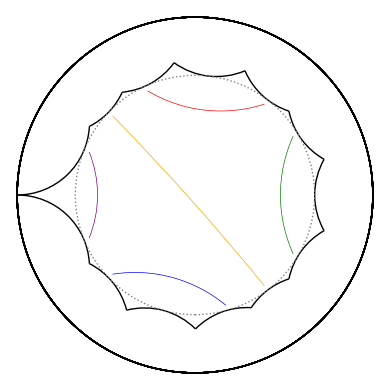

In [28]:
identifications2=plot(PD.get_geodesic(fd_midpoints2[1], fd_midpoints2[-1]), thickness=0.5, color='green')
identifications2+=plot(PD.get_geodesic(fd_midpoints2[2], fd_midpoints2[4]), thickness=0.5, color='red')
identifications2+=plot(PD.get_geodesic(fd_midpoints2[5], fd_midpoints2[11]), thickness=0.5, color='orange')
identifications2+=plot(PD.get_geodesic(fd_midpoints2[6], fd_midpoints2[7]), thickness=0.5, color='purple')
identifications2+=plot(PD.get_geodesic(fd_midpoints2[8], fd_midpoints2[10]), thickness=0.5)

polygon2=Graphics()
for edge in fd_edges2:
    polygon2+=plot(edge, axes=false, color='black')

fundamental_domain2=polygon2+identifications2

fundamental_domain2+circle((0,0), r_euc, color='gray', thickness=1, linestyle='dotted')

In [29]:
#The following function plots the image of the fundamental domain by an isometry.
#Inputs: g (isometry in the Poincaré disc model), col ('str'), style ('str', default='-'), w ('float', default='1')
#Outputs: It returns a figure with the image by g of the fundamental domain, where the lines have color col, linestyle style and thickness w.

def movepolygon2(g, col, style='-', w=1):
    global fd_edges2
    g_fd=Graphics()
    g_fd_edges=[g*edge for edge in fd_edges2]
    for j in [0..m-1]:
        g_fd+=plot(g_fd_edges[j], color=col, axes=False, linestyle=style, thickness=w)
    return g_fd

In [30]:
#Definition of the side-pairing transformations:
ref2=[]
for j in [0..len(fd_edges2)-1]:
    ref2.append(fd_edges2[j].reflection_involution())

    
simbas2_1=PD.get_geodesic(fd_midpoints2[0],PD(0+0*I)).reflection_involution()
simbas2_2=PD.get_geodesic(fd_midpoints2[3],PD(0+0*I)).reflection_involution()
simbas2_3=PD.get_geodesic(fd_vertices2[7],PD(0+0*I)).reflection_involution()
simbas2_4=PD.get_geodesic(fd_midpoints2[9],PD(0+0*I)).reflection_involution()

g_mid=PD.get_geodesic(fd_midpoints2[5],fd_midpoints2[-2])
simbas2_5=g_mid.perpendicular_bisector().reflection_involution()

side_pairings2=[ref2[0],simbas2_1*ref2[1],simbas2_2*ref2[2],ref2[3],simbas2_2*ref2[4],simbas2_5*ref2[5],simbas2_3*ref2[6]]
side_pairings2+=[simbas2_3*ref2[7],simbas2_4*ref2[8],ref2[9],simbas2_4*ref2[10],simbas2_5*ref2[11],simbas2_1*ref2[12]]

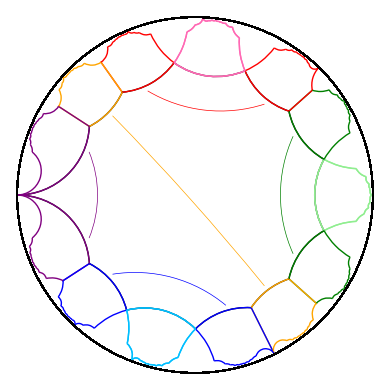

In [31]:
polygon_color2=fundamental_domain2
list2=[0,1,2,3,5,6,8,9]
col2=['lightgreen','green','red','hotpink','orange','purple','blue','deepskyblue']

for j in [0..len(list2)-1]:
    polygon_color2+=movepolygon2(side_pairings2[list2[j]], col2[j])+movepolygon2(side_pairings2[list2[j]]^(-1), col2[j])
polygon_color2

### Search of the preimages of extremal disc centers using the "bananas' method".

In [32]:
#Construction of a short list of admissible distances:
lst_index2=[[j] for j in [0..m-1]]
origin=PD(0+0*I)
ln=2

for i in range(ln):
    lst_index_aux=copy(lst_index2)
    for lst in lst_index_aux:
        for j in [0..m-1]:
            lst_index2+=[lst+[j]]

distances_list2=[]
simbas=PD.get_geodesic(1,-1).reflection_involution()

for lst in lst_index2: #Construction of isometries given as the product of at most three side-pairings of the fundamental domain.
    g=simbas*simbas^(-1)
    for j in [0..len(lst)-1]: g*=side_pairings2[lst[j]]
    pt=g*origin
    distances_list2+=[(origin.dist(pt), lst, g , g.classification())]

In [33]:
#Refinement of the distances in distances_list2, taking out the elements that repeat previous admissible distances:
distances_list2.sort()
distances_list_ref2=[]
k=0

while distances_list2[k][0]==0: k+=1

distances_list_ref2+=[distances_list2[k]]

for j in [k..len(distances_list2)-2]:
    if abs(distances_list2[j+1][0]-distances_list2[j][0])>10^(-5):
        distances_list_ref2+=[distances_list2[j+1]]
len(distances_list_ref2)

326

In [34]:
#The first two distances of distances_list_ref2 coincide with the first two admissible distances we know theoretically.
abs(distances_list_ref2[0][0]-fd_first_distance), N(abs(distances_list_ref2[1][0]-fd_second_distance))

(1.03916875104915e-13, 1.02140518265514e-14)

In [35]:
#Refinement of the isometries in distances_list2, taking out the elements that repeat previous isometries:
list_by_distances2=[[] for j in [0..len(distances_list_ref2)-1]] #We group isometries by their associated admissible distances.
l=0
d=distances_list_ref2[0][0]

for j in [k..len(distances_list2)-1]:
    if abs(distances_list2[j][0]-d)<10^(-3): list_by_distances2[l]+=[distances_list2[j]]
    else:
        list_by_distances2[l+1]+=[distances_list2[j]]
        l+=1
        d=distances_list_ref2[l][0]
        
isometries_t2=[]
for k in [0..len(list_by_distances2)-1]:
    isometries=[]
    for j in [0..len(list_by_distances2[k])-1]:
        test=0
        s=0
        isometry=list_by_distances2[k][j][2]
        while test==0 and s<len(isometries):
            a=(isometry*PD(0)).coordinates()-(isometries[s]*PD(0)).coordinates()
            b=(isometry*PD(1/2)).coordinates()-(isometries[s]*PD(1/2)).coordinates()
            c=(isometry*PD(-1/2)).coordinates()-(isometries[s]*PD(-1/2)).coordinates()
            if abs(a)<10^(-5) and abs(b)<10^(-5) and abs(c)<10^(-5) and (isometry*isometries[s]).preserves_orientation()==True:
                test=1 #isometry*isometries[s]==Id.
            s+=1
        if test==0: 
            isometries+=[isometry]
    isometries_t2+=isometries

Once we have computed a reasonable amount of admissible distances of this extremal disc configuration, we are going to plot the a set of bananas needed to cover the whole fundamental domain with the closure of the regions they bound.

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/plot/contour_plot.py:208: UserWarning: No contour levels were found within the data range.
  linewidths=linewidths, linestyles=linestyles)


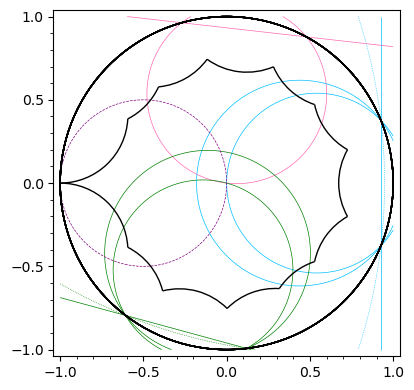

In [36]:
good_side_pairings2=[]

for g in side_pairings2:
    if g.classification()=='hyperbolic' or g.classification()=='orientation-reversing hyperbolic':
        good_side_pairings2.append(g)

polygon_bananas2_1=polygon2
list2_2=[0,1,4]
col2_2=['deepskyblue','hotpink','green']

for k in [0..len(list2_2)-1]:
    polygon_bananas2_1+=banana(good_side_pairings2[list2_2[k]],fd_first_distance,col2_2[k])

polygon_bananas2_1+=banana(good_side_pairings2[list2_2[0]],fd_second_distance,col2_2[0])
polygon_bananas2_1+=banana(good_side_pairings2[list2_2[2]],fd_second_distance,col2_2[2])
polygon_bananas2_1+=bananapar(3*gamma+beta+3*alpha,distances_list_ref2,0,'purple')

polygon_bananas2_1.show(ymax=1, ymin=-1)

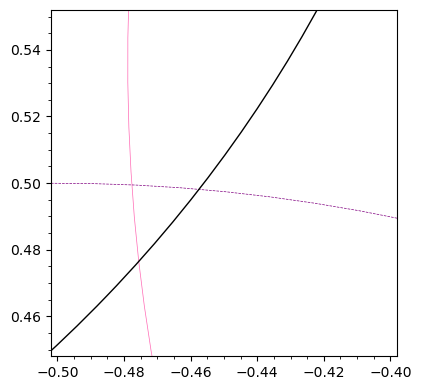

In [37]:
polygon_bananas2_1.show(xmin=-0.5,xmax=-0.4,ymin=0.45,ymax=0.55) #The intersection point is outside the fundamental domain.

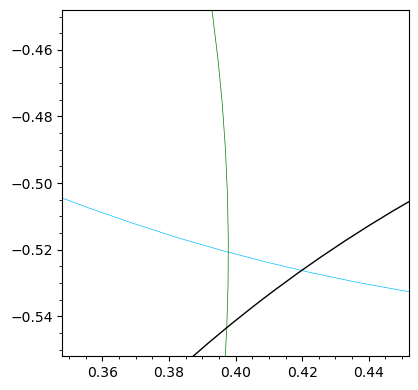

In [38]:
polygon_bananas2_1.show(xmin=0.35,xmax=0.45,ymin=-0.55,ymax=-0.45)

As fd_first_distance and fd_second_distance are the two smallest admissible distances, we do not have to calculate more bananas: if d1\<d2, the bananas of a hyperbolic isometry s associated to the distance d1 are contained in the region bounded by the bananas of s associated to the distance d2, while the banana of a parabolic transformation s associated to d1 is a horocycle contained in the horoball bounded by the banana of s associated to the distance d2. Therefore, as the closure of the regions bounded by the bananas represented in the previous figure cover all the fundamental domain, we do not have to take more bananas: if a point is at the interior of the region bounded by the bananas associated to the distance fd_first_distance, there is no admissible banana of this side-pairing that passes through this point and the same happens in the interior of the region bounded by the bananas of good_side_pairings2[k] associated to fd_second_distance minus the region bounded by the bananas of good_side_pairings2[k] associated to fd_first_distance for k=0,4.

In particular, the preimages of the extremal disc centers must be on the bananas illustrated in the previous figure. In fact, if we consider the open sets given by the interior of the regions described previously and we take their union, we will be covering all the points of the fundamental domain except two, one of them the origin (which we know is the preimage of an extremal disc centre by construction). Therefore, we only need to analyse the situation of the other special point, which is the only other candidate to be the preimage of an extremal disc center. In the previous figure, there are only blue and green bananas intersecting at this point. Now, we will see that there cannot be any orange banana passing through this point, so it cannot be the preimage of an extremal disc center.

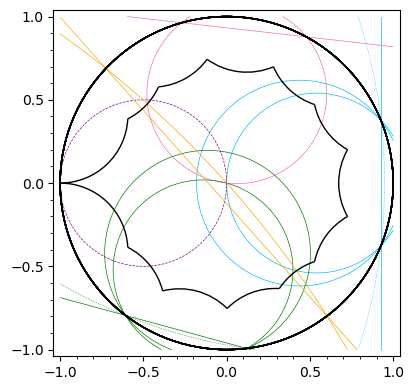

In [39]:
polygon_bananas2_2=polygon_bananas2_1

polygon_bananas2_2+=banana(side_pairings2[5], fd_first_distance, 'orange')

polygon_bananas2_2.show(ymin=-1,ymax=1)

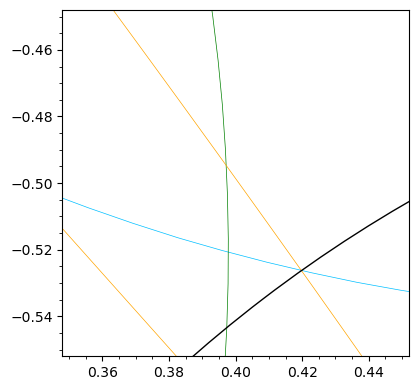

In [40]:
polygon_bananas2_2.show(xmin=0.35,xmax=0.45,ymin=-0.55,ymax=-0.45)

The special point is inside the region bounded by the hyperbolic bananas of side_pairings2[5] associated to the first admissible distance fd_first_distance and there is no admissible banana of side_pairings2[5] passing through any point in that region, so this point is not the preimage of an extremal disc center. We can numerically see that it does not move properly under that side-pairing:

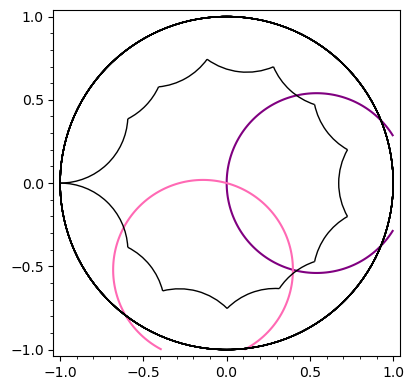

In [41]:
banana1_2=banana(good_side_pairings2[list2_2[0]],fd_first_distance)[0]
banana2_2=banana(good_side_pairings2[list2_2[2]],fd_first_distance)[0]

implicit_plot(banana1_2,(x, -1, 1),(y, -1, 1),color='purple')+implicit_plot(banana2_2,(x, -1, 1),(y, -1, 1),color='hotpink')+polygon2

In [42]:
coord_intersection(banana1_2,banana2_2)

[1.80411241501588e-15 - 1.88737914186277e-15*I,
 0.397861600235706 - 0.520790833185151*I]

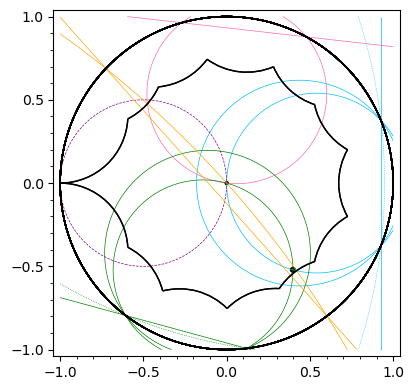

In [43]:
intersection_p2=coord_intersection(banana1_2,banana2_2)[1]
bananas_point2=polygon2+polygon_bananas2_2+points([intersection_p2],color='black', size='20')+points([0+0*I],color='black')
bananas_point2.show(ymin=-1,ymax=1)

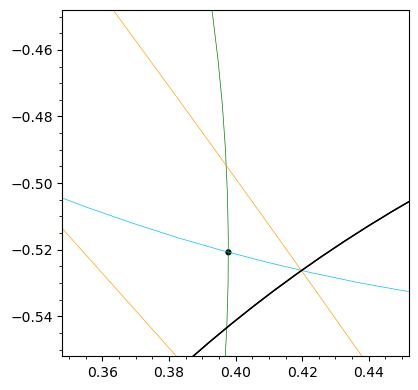

In [44]:
bananas_point2.show(xmin=0.35,xmax=0.45,ymin=-0.55,ymax=-0.45)

In [45]:
(side_pairings2[5]*PD(intersection_p2)).dist(PD(intersection_p2)), fd_first_distance

(3.25793043656981, 3.263355322001952)

As the origin is the only candidate to be the preimage of an extremal disc center in the fundamental domain, the extremal sphere with one puncture and three boundary components described by this extremal disc configuration has exactly one extremal disc, centered at the projection of the origin.

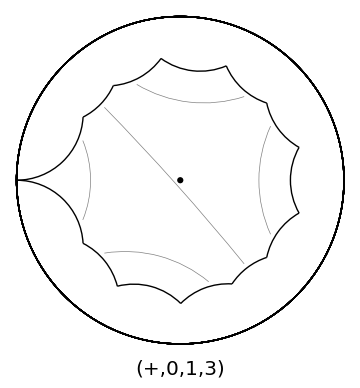

In [46]:
identifications_g2=plot(PD.get_geodesic(fd_midpoints2[-1], fd_midpoints2[1]), thickness=0.5, color='gray')
identifications_g2+=plot(PD.get_geodesic(fd_midpoints2[2], fd_midpoints2[4]), thickness=0.5, color='gray')
identifications_g2+=plot(PD.get_geodesic(fd_midpoints2[5], fd_midpoints2[11]), thickness=0.5, color='gray')
identifications_g2+=plot(PD.get_geodesic(fd_midpoints2[6], fd_midpoints2[7]), thickness=0.5, color='gray')
identifications_g2+=plot(PD.get_geodesic(fd_midpoints2[8], fd_midpoints2[10]), thickness=0.5, color='gray')

polygon_art2=polygon2+identifications_g2+points([0+0*I], color='black', size=20)+text('(+,0,1,3)', (0,-1.15), fontsize='x-large', color='black')
polygon_art2

In both fundamental domains, the origin is the only preimage of an extremal disc center in the corresponding surface. Then, each extremal disc configuration clearly define a different extremal surface, as the Dirichlet domains centered at the preimage of the center of the unique extremal disc in each of these surfaces are non-isometric, so there are exactly two extremal spheres with one puncture and three boundary components.